In [1]:
"""
Exemple d'utilisation de la méthode SPV (Split Pseudo-Voigt) 
pour calculer la position d'un pic à partir de données I(q)
"""
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from saxsprocessor import SAXSProcessor
import os
import glob

# ============================================================================
# MÉTHODE 1 : Analyse d'une seule expérience
# ============================================================================

frame_numbers = np.arange(20,26,2)
path = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/'
mask = path + 'amask_pyfai_LE.edf'

filelist=[]
for frame in frame_numbers:
    file_pattern = os.path.join(path, f'*{frame:05d}-{frame+1:05d}*.edf')
    matched_files = glob.glob(file_pattern)
    filelist.extend(matched_files)
print(f"Fichiers trouvés: ")
for file in filelist:
    print(file)

# compute average intensity
total_int = []
for file in filelist:
    
    proc = SAXSProcessor(file, mask = mask, instrument='LGC') 
    total_int.append(proc.data)

mean_int=np.mean(total_int,axis=0)



Fichiers trouvés: 
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00020-00021.edf
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00022-00023.edf
/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/FlowCellMagnet_0_vd_00024-00025.edf


✅ SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/Theo_LGC/saxs_images/TDFeNp34_non_lavee_H400mT_Img_20.png


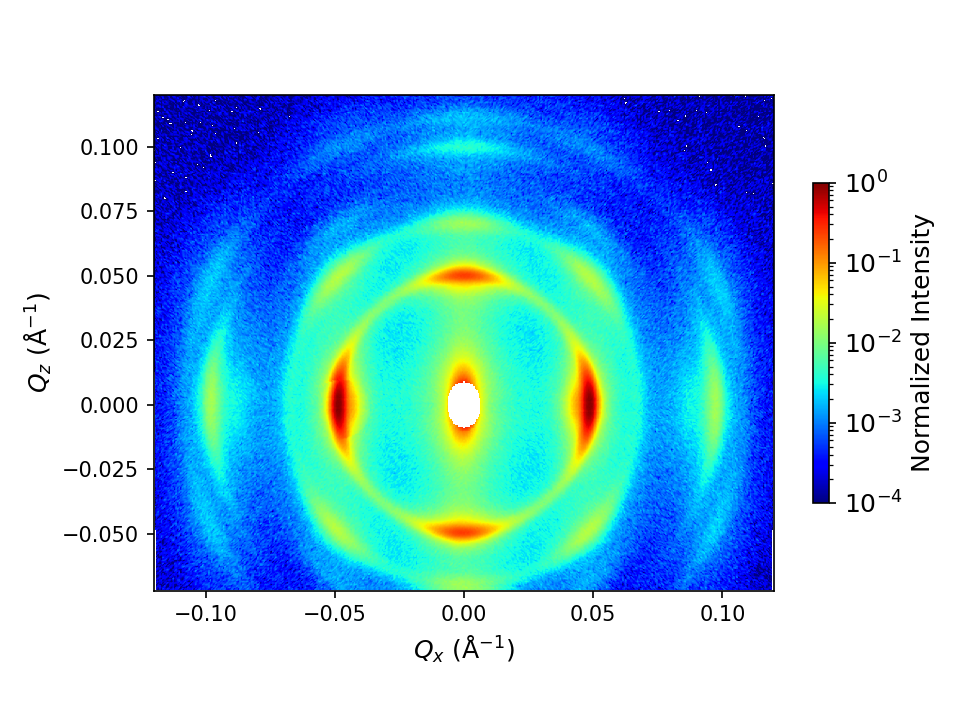

In [2]:
# create saxs processor instance with this mean intensity
proc = SAXSProcessor(filelist[0], mask = mask, instrument='LGC') 
proc.data = mean_int  # assign mean intensity to data
proc.plot2d_vsq(q_range=[0,0.12])


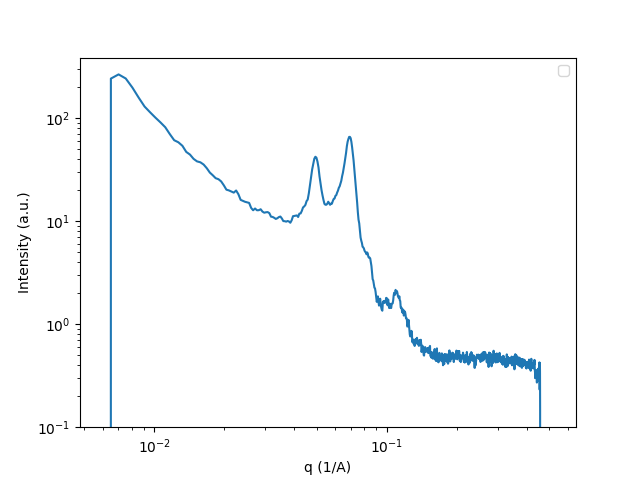

In [3]:
q,I=proc.extract_radial_profile(azimuth=-45,width=10)
plt.figure()
plt.loglog(q,I)
plt.xlabel('q (1/A)')
plt.ylabel('Intensity (a.u.)')
plt.legend()

**recherche de pics avec méthode de la dérivée seconde**

⚠ Paramètres ignorés pour la méthode 'derivative' : fit_window_width, verbose


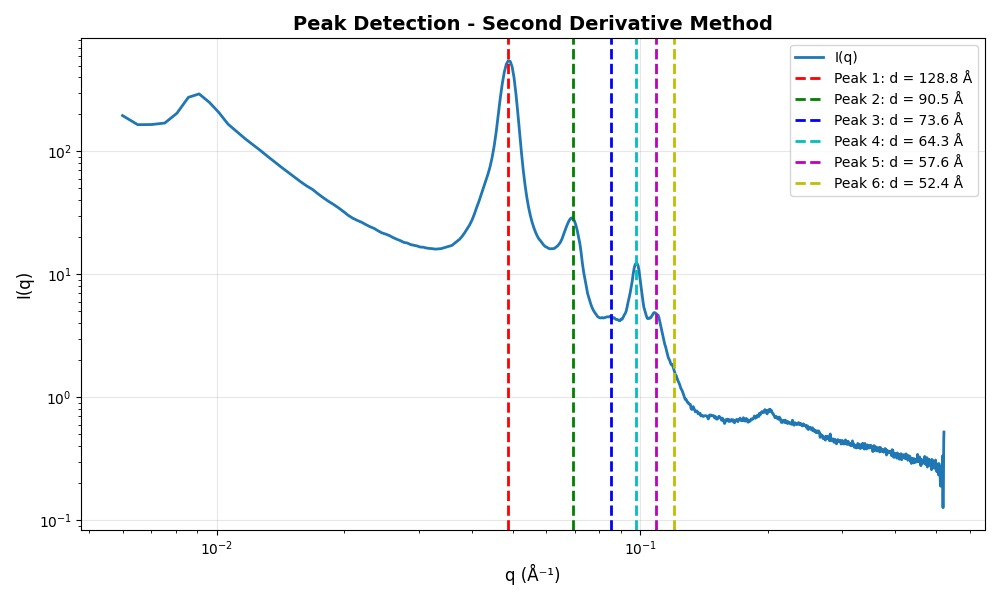


Analyse de Distance de Corrélation
Échantillon : TDFeNp34_non_lavee_H400mT
Méthode     : DERIVATIVE
Secteur     : 90° ± 180.0°

6 pic(s) détecté(s) :
  Pic 1: q = 0.0488 Å⁻¹ → d = 128.8 Å
  Pic 2: q = 0.0694 Å⁻¹ → d = 90.5 Å
  Pic 3: q = 0.0854 Å⁻¹ → d = 73.6 Å
  Pic 4: q = 0.0978 Å⁻¹ → d = 64.3 Å
  Pic 5: q = 0.1091 Å⁻¹ → d = 57.6 Å
  Pic 6: q = 0.1199 Å⁻¹ → d = 52.4 Å
⚠ Paramètres ignorés pour la méthode 'spv' : prominence


/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/saxs_analysis.py:1603: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


[File:TDFeNp34_non_lavee_H400mT_correlation][6/6] SPV peak finding failed: [File:TDFeNp34_non_lavee_H400mT_correlation_working_experiment_6] No peaks detected during standard peak search.


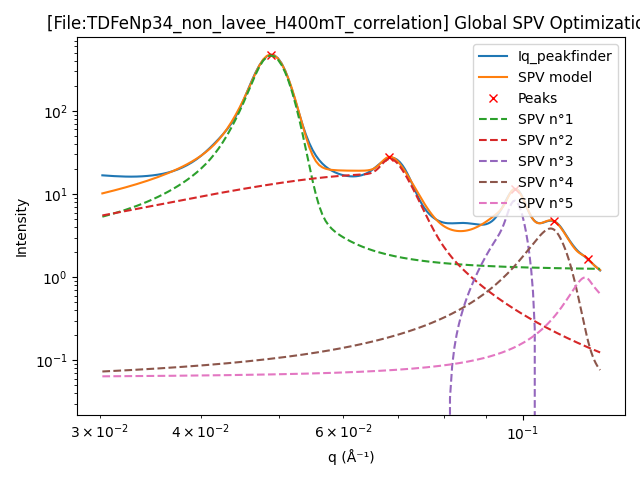


Analyse de Distance de Corrélation
Échantillon : TDFeNp34_non_lavee_H400mT
Méthode     : SPV
Secteur     : 90° ± 180.0°

5 pic(s) détecté(s) :
  Pic 1: q = 0.0488 ± 0.0024 Å⁻¹ → d = 128.8 ± 6.4 Å
          FWHM = 0.0044 Å⁻¹
  Pic 2: q = 0.0684 ± 0.0034 Å⁻¹ → d = 91.9 ± 4.6 Å
          FWHM = 0.0245 Å⁻¹
  Pic 3: q = 0.0978 ± 0.0049 Å⁻¹ → d = 64.3 ± 3.2 Å
          FWHM = 0.0080 Å⁻¹
  Pic 4: q = 0.1091 ± 0.0055 Å⁻¹ → d = 57.6 ± 2.9 Å
          FWHM = 0.0083 Å⁻¹
  Pic 5: q = 0.1205 ± 0.0060 Å⁻¹ → d = 52.2 ± 2.6 Å
          FWHM = 0.0076 Å⁻¹


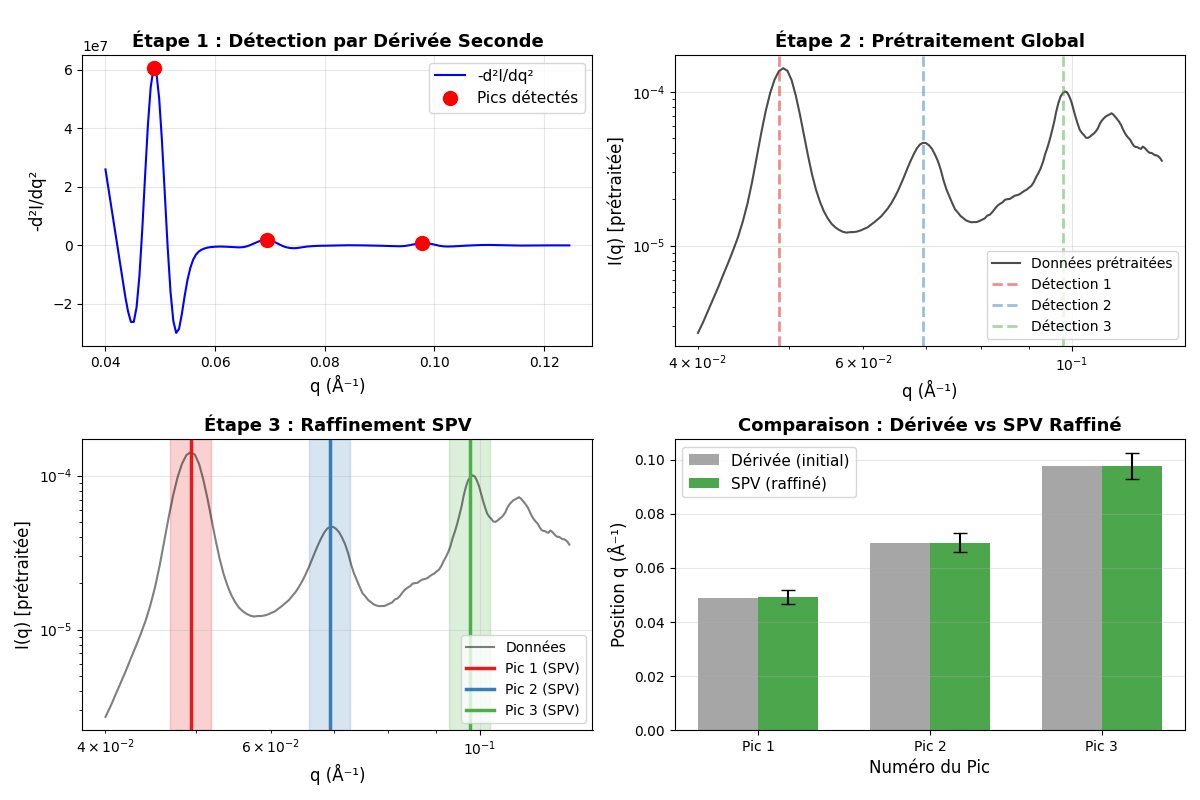


Analyse de Distance de Corrélation
Échantillon : TDFeNp34_non_lavee_H400mT
Méthode     : HYBRID
Secteur     : -45° ± 180.0°

3 pic(s) détecté(s) :
  Pic 1:
    Dérivée : q = 0.0488 Å⁻¹
    SPV     : q = 0.0493 ± 0.0025 Å⁻¹ → d = 127.4 ± 6.4 Å
    Δq = 0.0005 Å⁻¹ (1.06%)
    FWHM = 0.0037 Å⁻¹
  Pic 2:
    Dérivée : q = 0.0694 Å⁻¹
    SPV     : q = 0.0694 ± 0.0035 Å⁻¹ → d = 90.5 ± 4.5 Å
    Δq = 0.0000 Å⁻¹ (0.00%)
    FWHM = 0.0100 Å⁻¹
  Pic 3:
    Dérivée : q = 0.0978 Å⁻¹
    SPV     : q = 0.0978 ± 0.0049 Å⁻¹ → d = 64.3 ± 3.2 Å
    Δq = 0.0000 Å⁻¹ (0.00%)
    FWHM = 0.0206 Å⁻¹

Ordre loi de puissance : m = 5.00


In [7]:
from correlationdistancecalculator import CorrelationDistanceCalculator

corr= CorrelationDistanceCalculator(proc)
# Second derivative method (no uncertainties computed - less accurate)
distances_deriv, err , _ = corr.compute_correlation_distances(
        nb_peaks=6,
        azimuth=90,
        width=360,
        plot=True,
        qmax=0.125,
        qmin=0.03,
        
        # method specific parameters
        method='derivative', # or 'derivative'
        window_length=15, # savitzky-golay filter window length
        polyorder=3, # savitzky-golay filter polynomial order
        prominence=0.5, # peak prominence definded in scipy find_peaks
        distance_pts=20,  # minimal distance between peaks in number of points 
        fit_window_width=1.5, # width of the fitting window around each detected peak (in 1/A)
        verbose=False  
    )
# Use SPV method
distances_spv, distances_std_spv, _ = corr.compute_correlation_distances(
       nb_peaks=6,
        azimuth=90,
        width=360,
        plot=True,
        qmax=0.125,
        qmin=0.03,
        verbose=False,
        # method specific parameters
        method='spv', 
        prominence=0.5, # peak prominence definded in scipy find_peaks
        subtract_power_law=False,# subtract power law background
        power_law_method='cancel', # 'feat' or 'cancel'
        power_law_order=None, # order of power law to subtract (None for automatic)
        power_law_range=(2.5, 5.0), # q-range for power law fitting
        smooth = True, # apply gaussian smoothing to the data
        smooth_sigma = 2 # sigma for gaussian smoothing
        )

# Use hybrid method : détection initiale par dérivée + raffinement SPV
distances_hybrid, distances_std_hybrid, _ = corr.compute_correlation_distances(
        nb_peaks=3,
        azimuth=-45,
        width=360,
        method='hybrid',
        qmin=0.04,
        qmax=0.125,
        # Détection initiale (dérivée)
        window_length=15,
        polyorder=3,
        prominence=0.5,
        distance_pts=20,
        # Raffinement SPV
        subtract_power_law=True,
        power_law_method='cancel',
        power_law_order=None,
        power_law_range=(2.5, 5.0),
        smooth=False,
        smooth_sigma=2,
        fit_window_width=1.5, 
        verbose=False,
        plot=True)
